<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/17_regression_crossval/17_1_SLR/17.1.3_SLR_Correlation_and_R_Squared.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Correlation and R-

Squared
Author: Brad Sheese
---
NOTE: If you want to save your work select the following from the menu above:**File  --> Save a copy in Drive**If you work on the copy you made all changes will be saved to Google Drive. If you do not save your own copy, you can work in 'playground mode' instead, and any changes you make will be lost after you're done.


In [2]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


## Introduction

In earlier notebooks we used correlation to describe the strength of relationships and saw that R-squared equals the square of the correlation. Now let's understand these statistics more deeply:

- **How is correlation computed?** What does the formula actually measure?- **Why is correlation unitless?** What happens when we change measurement units?- **What are correlation's limitations?** Can strong relationships have zero correlation?- **Where does R-squared come from?** What do SST, SSE, and SSR mean? These are foundational concepts that you will use throughout your study of statistics and machine learning.


## The Correlation Formula

Pearson's correlation coefficient ($r$) is computed as:$$r = \frac{1}{n-1} \sum_{i=1}^{n} \frac{x_i - \bar{x}}{s_x} \cdot \frac{y_i - \bar{y}}{s_y}$$Where:- $n$ is the number of observations- $\bar{x}$ and $\bar{y}$ are the sample means- $s_x$ and $s_y$ are the sample standard deviationsEach term $\frac{x_i - \bar{x}}{s_x}$ is a **z-score**: how many standard deviations $x_i$ is from its mean.

So correlation is the **average product of z-scores**.

Let's see what this means intuitively:- When both $x$ and $y$ are **above** their means: positive x positive = **positive** contribution- When both $x$ and $y$ are **below** their means: negative x negative = **positive** contribution- When one is above and one is below: positive x negative = **negative** contribution

So $r$ is **positive** when points tend to trend up-right (both above or both below together), and **negative** when points trend down-right (one above while the other is below).


### Computing Correlation from 

Scratch

Let's compute $r$ step by step on a small dataset, following the formula exactly.


In [3]:
# Small fabricated dataset
x = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
y = np.array([2.1, 3.8, 6.2, 7.9, 10.1, 12.0, 14.2, 15.8, 18.1, 19.9])
n = len(x)

# Step 1: Compute means
x_mean = np.mean(x)
y_mean = np.mean(y)
print("x mean: {:.1f}".format(x_mean))
print("y mean: {:.1f}".format(y_mean))
print()

# Step 2: Compute standard deviations (sample std, ddof=1)
x_std = np.std(x, ddof=1)
y_std = np.std(y, ddof=1)
print("x std: {:.2f}".format(x_std))
print("y std: {:.2f}".format(y_std))
print()

# Step 3: Compute z-scores
x_z = (x - x_mean) / x_std
y_z = (y - y_mean) / y_std
print("Z-scores:")
for i in range(n):
    print("  Point {}: x_z = {:.3f},  y_z = {:.3f},  product = {:.3f}".format(
        i+1, x_z[i], y_z[i], x_z[i]*y_z[i]))
print()

# Step 4: Average of products
r_manual = np.sum(x_z * y_z) / (n - 1)
print("Correlation (from scratch): r = {:.4f}".format(r_manual))

# Verify against numpy
r_numpy = np.corrcoef(x, y)[0, 1]
print("Correlation (numpy):        r = {:.4f}".format(r_numpy))
print("Match: {}".format(np.isclose(r_manual, r_numpy)))


x mean: 5.5
y mean: 11.0

x std: 3.03
y std: 6.04

Z-scores:
  Point 1: x_z = -1.486,  y_z = -1.475,  product = 2.192
  Point 2: x_z = -1.156,  y_z = -1.194,  product = 1.380
  Point 3: x_z = -0.826,  y_z = -0.796,  product = 0.657
  Point 4: x_z = -0.495,  y_z = -0.515,  product = 0.255
  Point 5: x_z = -0.165,  y_z = -0.151,  product = 0.025
  Point 6: x_z = 0.165,  y_z = 0.164,  product = 0.027
  Point 7: x_z = 0.495,  y_z = 0.528,  product = 0.262
  Point 8: x_z = 0.826,  y_z = 0.793,  product = 0.655
  Point 9: x_z = 1.156,  y_z = 1.174,  product = 1.357
  Point 10: x_z = 1.486,  y_z = 1.472,  product = 2.187

Correlation (from scratch): r = 0.9997
Correlation (numpy):        r = 0.9997
Match: True


### Visual Intuition: QuadrantsThe scatterplot below is divided into four quadrants by the mean lines.

Points in the top-right and bottom-left quadrants contribute **positively** to the correlation.

Points in the top-left and bottom-right contribute **negatively**.


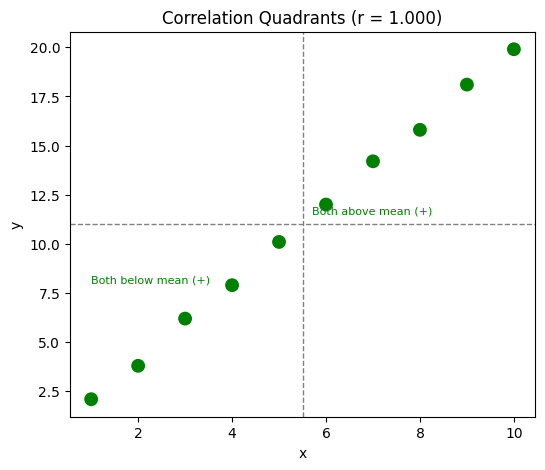

Green points: 10 (positive contribution to r)
Red points: 0 (negative contribution to r)


In [4]:
fig, ax = plt.subplots(figsize=(6, 5))

# Color-code by quadrant
colors = []
for i in range(n):
    if (x[i] > x_mean and y[i] > y_mean) or (x[i] < x_mean and y[i] < y_mean):
        colors.append('green')  # positive contribution
    else:
        colors.append('red')  # negative contribution

ax.scatter(x, y, c=colors, s=80, zorder=5)
ax.axvline(x=x_mean, color='gray', linestyle='--', linewidth=1)
ax.axhline(y=y_mean, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Correlation Quadrants (r = {:.3f})'.format(r_manual))
ax.text(x_mean + 0.2, y_mean + 0.5, 'Both above mean (+)', fontsize=8, color='green')
ax.text(x_mean - 4.5, y_mean - 3, 'Both below mean (+)', fontsize=8, color='green')
plt.show()

print("Green points: {} (positive contribution to r)".format(colors.count('green')))
print("Red points: {} (negative contribution to r)".format(colors.count('red')))


## Visual Gallery of Correlations

Correlation always falls between -1 and +1.

Let's see what different values look like.

### The Coefficient of Determination

R-squared is also called the **coefficient of determination**. It tells us the proportion of total variability in the outcome that is "determined" (explained) by the linear model. For simple linear regression with one predictor, the coefficient of determination equals the square of the correlation: $R^2 = r^2$.


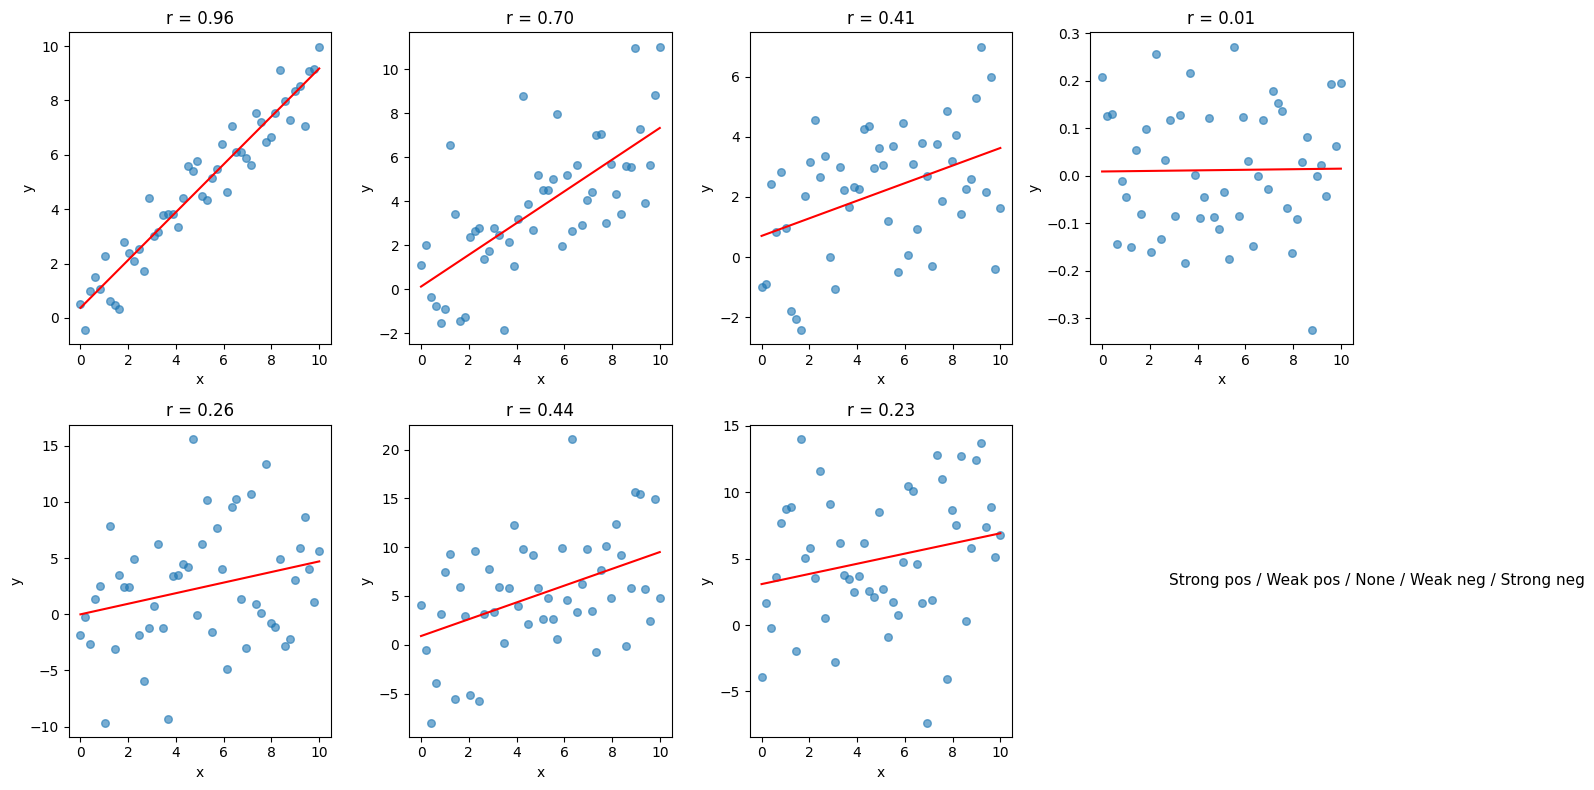

In [5]:
np.random.seed(42)
n_gal = 50
x_gal = np.linspace(0, 10, n_gal)

# Create datasets with different noise levels to get different r values
targets = [0.95, 0.7, 0.4, 0.0, -0.4, -0.7, -0.95]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, target_r in enumerate(targets):
    # Start with perfect line, add noise until we hit target r
    for noise_scale in np.linspace(0.1, 5, 100):
        y_gal = target_r * x_gal + np.random.normal(0, noise_scale, n_gal)
        r = np.corrcoef(x_gal, y_gal)[0, 1]
        if abs(r - abs(target_r)) < 0.02 or (target_r == 0 and abs(r) < 0.05):
            break

    # Adjust sign if needed
    if target_r < 0:
        y_gal = -y_gal

    r_actual = np.corrcoef(x_gal, y_gal)[0, 1]

    axes[idx].scatter(x_gal, y_gal, alpha=0.6, s=30)
    axes[idx].plot(x_gal, np.polyval(np.polyfit(x_gal, y_gal, 1), x_gal),
                   color='red', linewidth=1.5)
    axes[idx].set_title('r = {:.2f}'.format(r_actual))
    axes[idx].set_xlabel('x')
    axes[idx].set_ylabel('y')

# Empty last panel
axes[7].axis('off')
axes[7].text(0.3, 0.5, 'Strong pos / Weak pos / None / Weak neg / Strong neg',
             fontsize=11, va='center')
axes[7].set_xlim(0, 1)
axes[7].set_ylim(0, 1)

plt.tight_layout()
plt.show()


### Interpreting Correlation Strength

As a rough guide:| |r| range | 

Strength ||
---
|
---
|| 0.7 - 1.0 | **Strong** linear relationship || 0.4 - 0.7 | **Moderate** linear relationship || 0.0 - 0.4 | **Weak** linear relationship |**Important caveats:**- These thresholds are context-dependent. In physics, r = 0.9 might be considered weak. In social sciences, r = 0.3 might be meaningful.- Sample size matters. With small samples, correlations can appear large by chance.- Correlation says nothing about causation.


## Correlation Is UnitlessOne of correlation's most important properties is that it is **unaffected by linear changes in units**.

Converting kilograms to pounds, centimeters to inches, or dollars to thousands of dollars does not change $r$ at all.

This is because z-scores are already unitless -- they measure how many standard deviations a value is from the mean, regardless of what units the original data used.


Original units (mm, g):     r = 0.5895
Converted units (in, lb):   r = 0.5895
Match: True



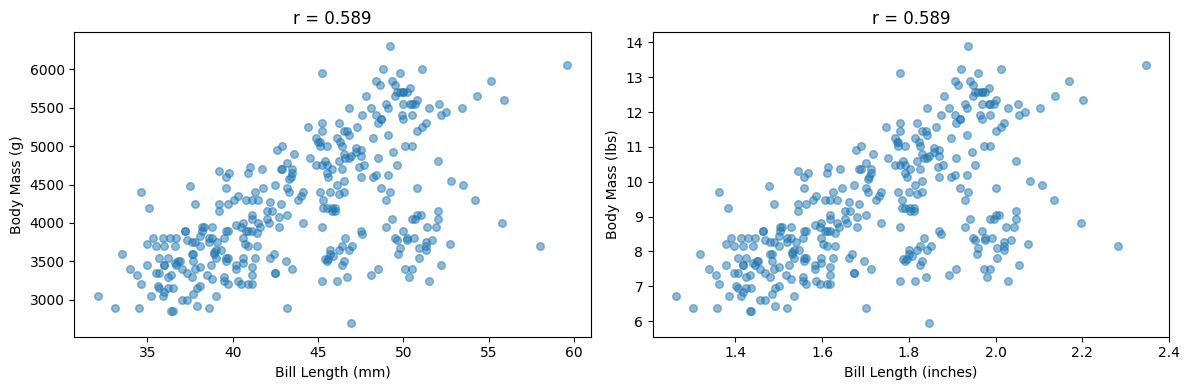

In [6]:
# Use penguins data: bill length vs. body mass
penguins = sns.load_dataset('penguins').dropna()

bill_mm = penguins['bill_length_mm'].values
mass_g = penguins['body_mass_g'].values

# Correlation in original units
r_original = np.corrcoef(bill_mm, mass_g)[0, 1]

# Convert: mm -> inches, grams -> pounds
bill_in = bill_mm / 25.4
mass_lb = mass_g / 453.592

# Correlation in converted units
r_converted = np.corrcoef(bill_in, mass_lb)[0, 1]

print("Original units (mm, g):     r = {:.4f}".format(r_original))
print("Converted units (in, lb):   r = {:.4f}".format(r_converted))
print("Match: {}".format(np.isclose(r_original, r_converted)))
print()

# Side-by-side scatterplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(bill_mm, mass_g, alpha=0.5, s=30)
axes[0].set_xlabel('Bill Length (mm)')
axes[0].set_ylabel('Body Mass (g)')
axes[0].set_title('r = {:.3f}'.format(r_original))
axes[1].scatter(bill_in, mass_lb, alpha=0.5, s=30)
axes[1].set_xlabel('Bill Length (inches)')
axes[1].set_ylabel('Body Mass (lbs)')
axes[1].set_title('r = {:.3f}'.format(r_converted))
plt.tight_layout()
plt.show()


### Contrast with Slope

While correlation is unitless, the **slope** of a regression line *does* change with units.

This is actually useful:- **Correlation** tells you the *strength and direction* of a linear relationship, independent of scale- **Slope** tells you the *rate of change* in specific units

Let's see this in action.


In [7]:
# Fit regression in both unit systems
X_mm = bill_mm.reshape(-1, 1)
X_in = bill_in.reshape(-1, 1)
y_g = mass_g.reshape(-1, 1)
y_lb = mass_lb.reshape(-1, 1)

model_g = LinearRegression().fit(X_mm, y_g)
model_lb = LinearRegression().fit(X_in, y_lb)

slope_g = model_g.coef_.item()
slope_lb = model_lb.coef_.item()

print("Slope (mm -> g):   {:.2f} grams per mm".format(slope_g))
print("Slope (in -> lb):  {:.2f} lbs per inch".format(slope_lb))
print()
print("Correlation (mm,g): {:.4f}".format(r_original))
print("Correlation (in,lb): {:.4f}".format(r_converted))
print()
print("The slopes are very different numbers, but the correlations are identical.")


Slope (mm -> g):   86.79 grams per mm
Slope (in -> lb):  4.86 lbs per inch

Correlation (mm,g): 0.5895
Correlation (in,lb): 0.5895

The slopes are very different numbers, but the correlations are identical.


## Correlation Only Measures Linear RelationshipsThis is one of the most important caveats in all of statistics:> **A correlation near zero does NO

T mean the variables are unrelated.

It means they are not *linearly* related.**

Strong non-linear relationships can produce correlations near zero.


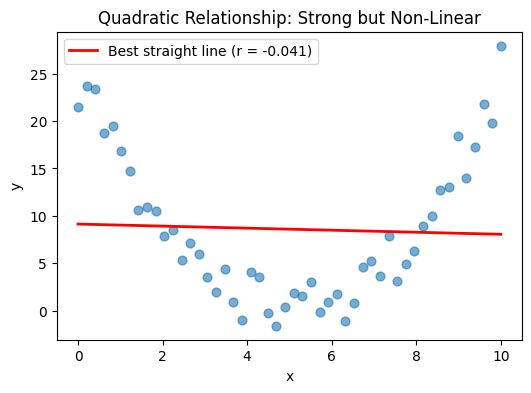

Correlation: r = -0.041
The variables are clearly related (U-shaped), but the correlation is near zero
because the relationship is not linear.


In [8]:
# Quadratic relationship
np.random.seed(100)
x_q = np.linspace(0, 10, 50)
y_q = (x_q - 5)**2 + np.random.normal(0, 2, 50)
r_q = np.corrcoef(x_q, y_q)[0, 1]

plt.figure(figsize=(6, 4))
plt.scatter(x_q, y_q, alpha=0.6, s=40)
plt.plot(x_q, np.polyval(np.polyfit(x_q, y_q, 1), x_q),
         color='red', linewidth=2, label='Best straight line (r = {:.3f})'.format(r_q))
plt.xlabel('x')
plt.ylabel('y')
plt.title('Quadratic Relationship: Strong but Non-Linear')
plt.legend()
plt.show()

print("Correlation: r = {:.3f}".format(r_q))
print("The variables are clearly related (U-shaped), but the correlation is near zero")
print("because the relationship is not linear.")


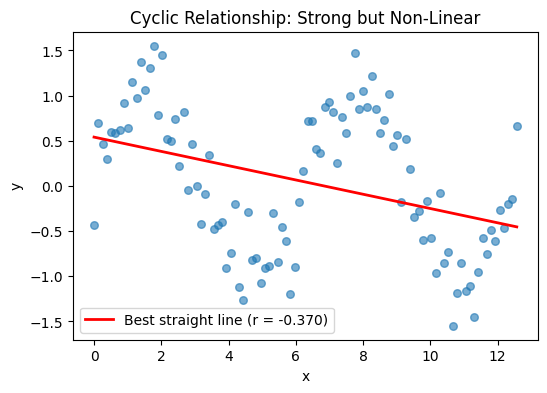

Correlation: r = -0.370
A strong periodic relationship with near-zero correlation.


In [9]:
# Cyclic (sine wave) relationship
np.random.seed(200)
x_c = np.linspace(0, 4 * np.pi, 100)
y_c = np.sin(x_c) + np.random.normal(0, 0.3, 100)
r_c = np.corrcoef(x_c, y_c)[0, 1]

plt.figure(figsize=(6, 4))
plt.scatter(x_c, y_c, alpha=0.6, s=30)
plt.plot(x_c, np.polyval(np.polyfit(x_c, y_c, 1), x_c),
         color='red', linewidth=2, label='Best straight line (r = {:.3f})'.format(r_c))
plt.xlabel('x')
plt.ylabel('y')
plt.title('Cyclic Relationship: Strong but Non-Linear')
plt.legend()
plt.show()

print("Correlation: r = {:.3f}".format(r_c))
print("A strong periodic relationship with near-zero correlation.")


### Anscombe's QuartetIn 1973, statistician Francis Anscombe created four datasets that have **nearly identical** summary statistics -- same mean, same variance, same correlation, same regression line -- but look completely different when plotted.

This is the classic demonstration that **you must always visualize your data**.

Summary statistics alone can be deeply misleading.

**Looking Ahead to 17.1.4:** You'll learn to use **residual plots** to diagnose model fit, identify **outliers** and **high leverage** points, and understand what makes a point an **influential point**. You will also learn about **leverage points** -- observations with extreme predictor values. You'll also see how the least squares line can be affected by unusual observations, and why **extrapolation** is risky. Finally, you'll learn how **indicator variables** let you include categorical predictors in your models.


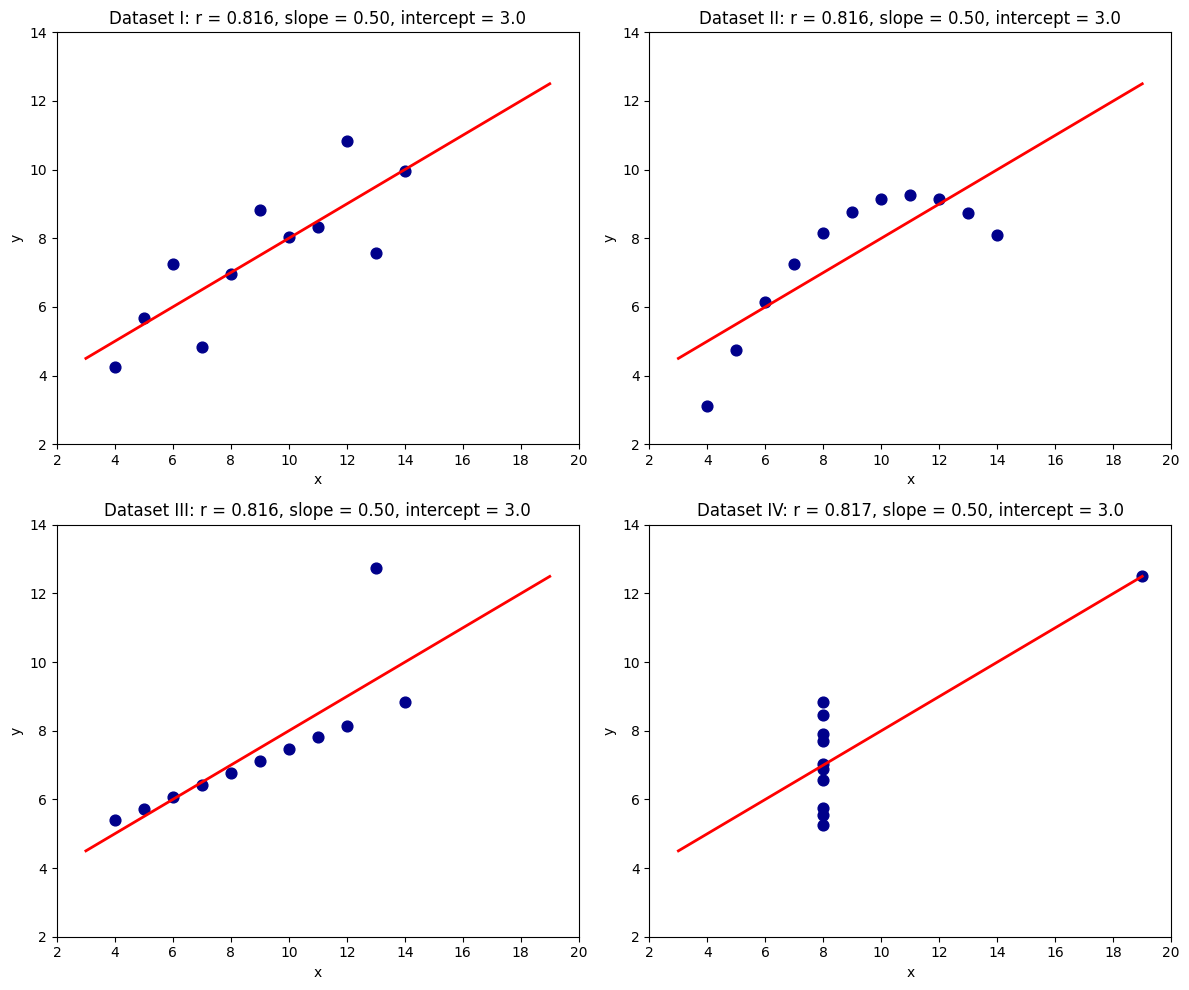

All four datasets have:
  Mean of x: 9.0
  Mean of y: 7.50
  Correlation: 0.816

But the relationships are completely different!


In [10]:
anscombe = sns.load_dataset('anscombe')

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, dataset in enumerate(['I', 'II', 'III', 'IV']):
    subset = anscombe[anscombe['dataset'] == dataset]
    x_a = subset['x'].values
    y_a = subset['y'].values

    # Fit regression line
    model_a = LinearRegression().fit(x_a.reshape(-1, 1), y_a)
    r_a = np.corrcoef(x_a, y_a)[0, 1]

    axes[i].scatter(x_a, y_a, s=60, color='darkblue')
    x_line = np.linspace(3, 19, 100)
    axes[i].plot(x_line, model_a.predict(x_line.reshape(-1, 1)),
                 color='red', linewidth=2)
    axes[i].set_title('Dataset {}: r = {:.3f}, slope = {:.2f}, intercept = {:.1f}'.format(
        dataset, r_a, model_a.coef_[0], model_a.intercept_))
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('y')
    axes[i].set_xlim(2, 20)
    axes[i].set_ylim(2, 14)

plt.tight_layout()
plt.show()

print("All four datasets have:")
print("  Mean of x: {:.1f}".format(anscombe['x'].mean()))
print("  Mean of y: {:.2f}".format(anscombe['y'].mean()))
print("  Correlation: {:.3f}".format(np.corrcoef(anscombe['x'], anscombe['y'])[0,1]))
print()
print("But the relationships are completely different!")


### Key 

Takeaway
- **Always plot your data** before computing summary statistics- A correlation near zero means "no *linear* relationship," not "no relationship"- Non-linear patterns (curves, cycles, clusters) can be hidden by a single correlation number


## R-Squared and the SST/SSE DecompositionWe've seen 

R-squared as the output of sklearn's `.score()` method.

Now let's understand where it comes from by decomposing the total variability in the outcome variable.


### Three Sums of SquaresThere are three key measures of variability in regression:**Total Sum of Squares (SST):**$$SST = \sum_{i=1}^{n} (y_i - \bar{y})^2$$

This measures the total variability in $y$ around its mean.

It's what you'd have if you predicted every $y$ as just the mean $\bar{y}$.**Sum of Squared Errors (SSE):**$$SSE = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 = \sum_{i=1}^{n} e_i^2$$This measures the leftover variability after the model -- the sum of squared residuals.**Regression Sum of Squares (SSR):**$$SSR = \sum_{i=1}^{n} (\hat{y}_i - \bar{y})^2$$This measures the variability explained by the model -- how much the predictions differ from the mean.**Key identity:**$$SST = SSR + SSE$$The total variability splits into what the model explains (SSR) plus what it doesn't (SS

E).


In [11]:
# Use the sugar/sweet data from earlier notebooks
np.random.seed(42)
sugar = np.arange(1, 11, 0.1)
sweet = np.array([(x/10) + np.random.uniform(-3, 3) for x in range(100)])

X_s = sugar.reshape(-1, 1)
y_s = sweet.reshape(-1, 1)

model_s = LinearRegression().fit(X_s, y_s)
y_pred_s = model_s.predict(X_s).flatten()
y_actual_s = sweet
y_mean_s = np.mean(y_actual_s)

# Compute SST, SSE, SSR
SST = np.sum((y_actual_s - y_mean_s) ** 2)
SSE = np.sum((y_actual_s - y_pred_s) ** 2)
SSR = np.sum((y_pred_s - y_mean_s) ** 2)

print("SST (total variability):    {:.2f}".format(SST))
print("SSR (explained by model):   {:.2f}".format(SSR))
print("SSE (leftover/unexplained): {:.2f}".format(SSE))
print("SSR + SSE = {:.2f}".format(SSR + SSE))
print("SST       = {:.2f}".format(SST))
print("Match: {}".format(np.isclose(SST, SSR + SSE)))


SST (total variability):    1169.36
SSR (explained by model):   854.08
SSE (leftover/unexplained): 315.29
SSR + SSE = 1169.36
SST       = 1169.36
Match: True


### R-Squared as a ProportionR-squared is the proportion of total variability that the model explains:$$R^2 = \frac{SSR}{SST} = \frac{SST - SSE}{SST} = 1 - \frac{SSE}{SST}$$- If $R^2 = 1$: the model explains 100% of the variation (SSE = 0, perfect fit)- If $R^2 = 0$: the model explains nothing (SSR = 0, the model is just the mean)- 

If $

R^2 = 0.64$: the model explains 64% of the variation


R2 from SSR/SST:       0.7304
R2 from 1-SSE/SST:     0.7304
R2 from sklearn:       0.7304
R2 from r2:            0.7304

Interpretation: 73.0% of the variation in perceived sweetness
is explained by sugar content.


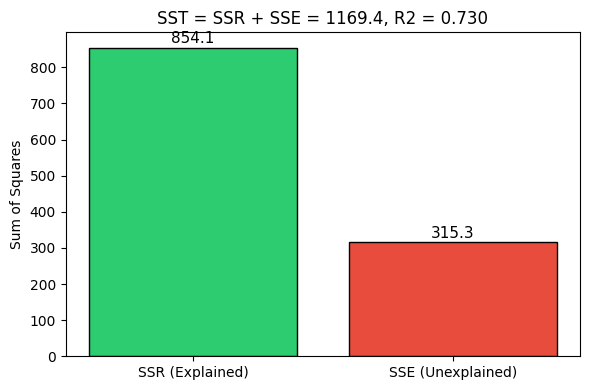

In [12]:
# Compute R^2 three ways
R2_from_sums = SSR / SST
R2_from_residuals = 1 - SSE / SST
R2_from_sklearn = model_s.score(X_s, y_s)
R2_from_r = np.corrcoef(sugar, sweet)[0, 1] ** 2

print("R2 from SSR/SST:       {:.4f}".format(R2_from_sums))
print("R2 from 1-SSE/SST:     {:.4f}".format(R2_from_residuals))
print("R2 from sklearn:       {:.4f}".format(R2_from_sklearn))
print("R2 from r2:            {:.4f}".format(R2_from_r))
print()
print("Interpretation: {:.1f}% of the variation in perceived sweetness".format(R2_from_sums*100))
print("is explained by sugar content.")

# Visual decomposition
fig, ax = plt.subplots(figsize=(6, 4))
categories = ['SSR (Explained)', 'SSE (Unexplained)']
values = [SSR, SSE]
colors = ['#2ecc71', '#e74c3c']
bars = ax.bar(categories, values, color=colors, edgecolor='black')
ax.set_ylabel('Sum of Squares')
ax.set_title('SST = SSR + SSE = {:.1f}, R2 = {:.3f}'.format(SST, R2_from_sums))
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            '{:.1f}'.format(val), ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()


### Comparing a Strong Model vs. a Weak ModelLet's see how the SST/SSR/SSE decomposition looks for a model with high 

R2 versus one with low 

R2.


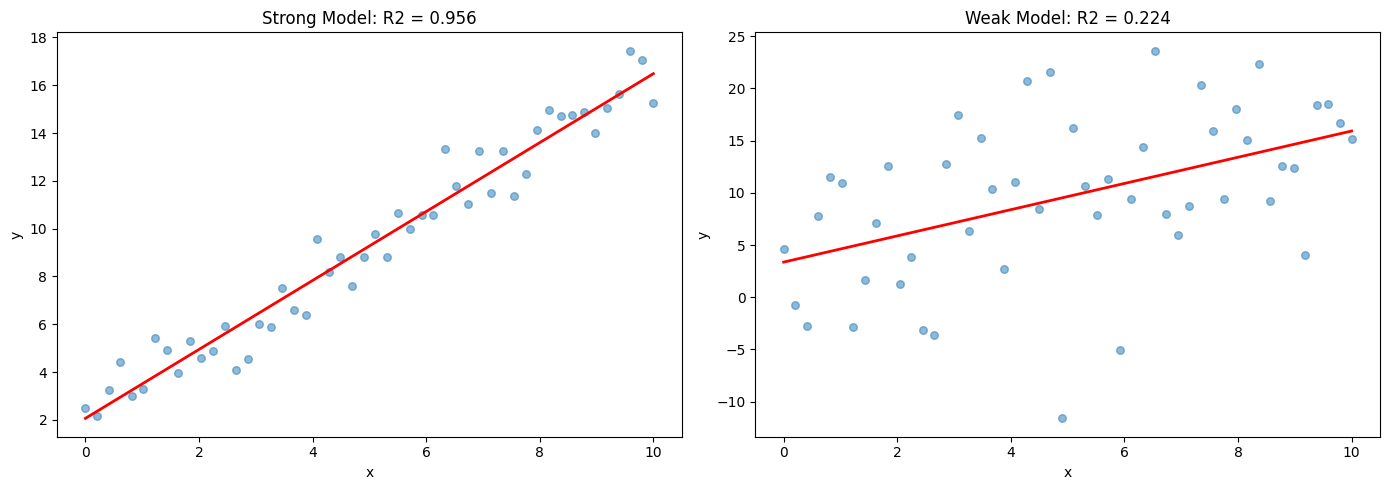

Strong model: R2 = 0.956  --> 96% of variation explained
Weak model:   R2 = 0.224  --> 22% of variation explained


In [13]:
np.random.seed(42)
n_comp = 50
x_comp = np.linspace(0, 10, n_comp)

# Strong model: low noise
y_strong = 2 + 1.5 * x_comp + np.random.normal(0, 1, n_comp)
X_strong = x_comp.reshape(-1, 1)
model_strong = LinearRegression().fit(X_strong, y_strong)
y_pred_strong = model_strong.predict(X_strong).flatten()
y_mean_strong = np.mean(y_strong)
SST_strong = np.sum((y_strong - y_mean_strong)**2)
SSR_strong = np.sum((y_pred_strong - y_mean_strong)**2)
SSE_strong = np.sum((y_strong - y_pred_strong)**2)
R2_strong = SSR_strong / SST_strong

# Weak model: high noise
y_weak = 2 + 1.5 * x_comp + np.random.normal(0, 8, n_comp)
model_weak = LinearRegression().fit(X_strong, y_weak)
y_pred_weak = model_weak.predict(X_strong).flatten()
y_mean_weak = np.mean(y_weak)
SST_weak = np.sum((y_weak - y_mean_weak)**2)
SSR_weak = np.sum((y_pred_weak - y_mean_weak)**2)
SSE_weak = np.sum((y_weak - y_pred_weak)**2)
R2_weak = SSR_weak / SST_weak

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Strong model
axes[0].scatter(x_comp, y_strong, alpha=0.5, s=30)
axes[0].plot(x_comp, y_pred_strong, color='red', linewidth=2)
axes[0].set_title('Strong Model: R2 = {:.3f}'.format(R2_strong))
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

# Weak model
axes[1].scatter(x_comp, y_weak, alpha=0.5, s=30)
axes[1].plot(x_comp, y_pred_weak, color='red', linewidth=2)
axes[1].set_title('Weak Model: R2 = {:.3f}'.format(R2_weak))
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')

plt.tight_layout()
plt.show()

print("Strong model: R2 = {:.3f}  --> {:.0f}% of variation explained".format(R2_strong, R2_strong*100))
print("Weak model:   R2 = {:.3f}  --> {:.0f}% of variation explained".format(R2_weak, R2_weak*100))


### The Connection:

R2 = r2 for Simple Linear Regression

For simple linear regression with one predictor,

R-squared is exactly the square of the correlation:$$R^2 = r^2$$

This makes sense: correlation measures the strength of the linear relationship (signed), and squaring it gives the proportion of variance explained (always positive).


In [14]:
# Verify on multiple datasets
datasets = {
    'Sugar/Sweet': (sugar, sweet),
    'Strong model': (x_comp, y_strong),
    'Weak model': (x_comp, y_weak),
    'Quadratic': (x_q, y_q),
}

print("{:<15} {:>8} {:>8} {:>8} {:>8}".format("Dataset", "r", "r2", "R2", "Match"))
print("-" * 50)
for name, (x_d, y_d) in datasets.items():
    r_d = np.corrcoef(x_d, y_d)[0, 1]
    r2_d = r_d ** 2
    X_d = x_d.reshape(-1, 1)
    model_d = LinearRegression().fit(X_d, y_d)
    R2_d = model_d.score(X_d, y_d)
    match = "Yes" if np.isclose(r2_d, R2_d) else "No"
    print("{:<15} {:>8.4f} {:>8.4f} {:>8.4f} {:>8}".format(name, r_d, r2_d, R2_d, match))


Dataset                r       r2       R2    Match
--------------------------------------------------
Sugar/Sweet       0.8546   0.7304   0.7304      Yes
Strong model      0.9779   0.9563   0.9563      Yes
Weak model        0.4732   0.2239   0.2239      Yes
Quadratic        -0.0411   0.0017   0.0017      Yes


## Practice 

Exercises


### Exercise 1: Compute r from Summary StatisticsYou are given the following summary statistics for a dataset:- Mean of x: 50,

Standard deviation of x: 10- 

Mean of y: 100,

Standard deviation of y: 20- Slope of the regression line: $b_1 = 1.5$Recall the formula: $b_1 = \frac{s_y}{s_x} \cdot r$

Solve for $r$ and verify your answer using the code cell below.


In [15]:
# Given values
x_mean = 50
x_std = 10
y_mean = 100
y_std = 20
b1 = 1.5

# Solve for r using: b1 = (sy/sx) * r
r_ex1 =

print("r = {:.4f}".format(r_ex1))


r = 0.7500

Reconstructed slope: 1.5000
Original slope: 1.5000
Match: True


### Exercise 2:

Interpret R-Squared in ContextA regression model predicting test scores from study hours has 

R2 = 0.64.

Write the correct interpretation of this 

R2 value in the code cell below.


In [16]:
interpretation = ""
print(interpretation)


64% of the variation in test scores is explained by study hours.


### Exercise 3: Non-Linear Relationship DiagnosisLook at the scatterplot below.

Without computing the correlation, estimate whether r is close to 0, moderately positive/negative, or strongly positive/negative.

Then compute it to check.


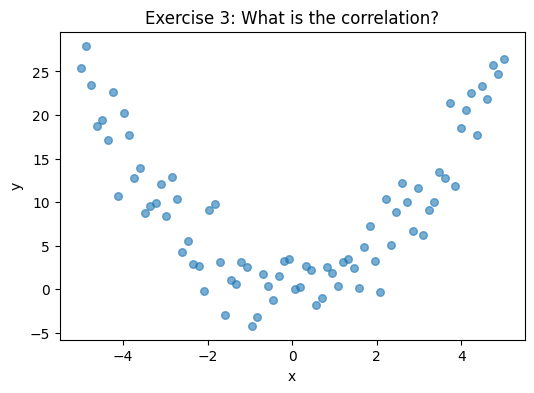

Actual correlation: 0.0585

The correlation is near zero despite the clear quadratic relationship.
A linear model is NOT appropriate for this data.


In [17]:
# Now compute it
r_ex3 =
print("Actual correlation: {:.4f}".format(r_ex3))


### Exercise 4: SST/SSE/R2 ComputationUsing the small dataset from the correlation walkthrough (x and y arrays defined earlier), compute SST,

SSE, and 

R2 by hand.

Verify against sklearn.


In [18]:
# Use the small dataset from earlier
x_small = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
y_small = np.array([2.1, 3.8, 6.2, 7.9, 10.1, 12.0, 14.2, 15.8, 18.1, 19.9])

# Fit the model
X_small = x_small.reshape(-1, 1)
model_small = LinearRegression().fit(X_small, y_small)
y_pred_small = model_small.predict(X_small).flatten()
y_mean_small = np.mean(y_small)

# Compute SST, SSE, SSR, R^2 by hand
SST_small =
SSE_small =
SSR_small =
R2_small =


SST = 328.41
SSR = 328.20
SSE = 0.21
SST = SSR + SSE? True
R2 = 0.9994
R2 from sklearn: 0.9994
Match: True


## Summary- **Correlation** ($r$) measures the strength and direction of a *linear* relationship, computed as the average product of z-scores- **Correlation is unitless**: changing measurement units does not change $r$- **Correlation only detects linear patterns**: strong non-linear relationships can have $r \approx 0$- **

Always visualize your data**:

Anscombe's quartet shows that identical summary statistics can hide completely different relationships- **R-squared** ($R^2$) = proportion of variance explained = $\frac{SSR}{SST} = 1 - \frac{SSE}{SST}$- For SLR: $R^2 = r^2$

In the next notebook, we'll look at how to visualize regression relationships by category and how to include categorical predictors in our models.

**In the next notebook (17.1.4)**, we will use these concepts to perform diagnostic checks on our models using **Residual Plots** to ensure that a linear model is actually appropriate for the data.
